In [78]:
GCAM_MAPPING = {
    "Africa_Eastern": ["Burundi","Comoros","Djibouti","Eritrea","Ethiopia","Kenya","Madagascar","Mauritius","Reunion","Rwanda","Sudan","Somalia","Uganda"],
    "Africa_Northern": ["Algeria","Egypt","Western Sahara","Libya","Morocco","Tunisia"],
    "Africa_Southern": ["Angola","Botswana","Lesotho","Mozambique","Malawi","Namibia","Swaziland","Tanzania","Zambia","Zimbabwe"],
    "Africa_Western": ["Benin","Burkina Faso","Central African Republic","Cote d'Ivoire","Cameroon","Democratic Republic of the Congo","Congo","Cape Verde","Gabon","Ghana","Guinea","Gambia","Guinea-Bissau","Equatorial Guinea","Liberia","Mali","Mauritania","Niger","Nigeria","Senegal","Sierra Leone","Sao Tome and Principe","Chad","Togo"],

    "Argentina": ["Argentina"],
    "Australia_NZ": ["Australia","New Zealand"],
    "Brazil": ["Brazil"],
    "Canada": ["Canada"],

    "CAC": ["Aruba","Anguilla","Netherlands Antilles","Antigua and Barbuda","Bahamas","Belize","Bermuda","Barbados","Costa Rica","Cuba","Cayman Islands","Dominica","Dominican Republic","Guadeloupe","Grenada","Guatemala","Honduras","Haiti","Jamaica","Saint Kitts and Nevis","Saint Lucia","Montserrat","Martinique","Nicaragua","Panama","El Salvador","Trinidad and Tobago","Saint Barthelemy","Sint Eustatius","Saba","Bonaire","Saint Vincent and the Grenadines"],

    "Central Asia": ["Armenia","Azerbaijan","Georgia","Kazakhstan","Kyrgyzstan","Mongolia","Tajikistan","Turkmenistan","Uzbekistan"],

    "China": ["China","Macau","Hong Kong"],
    "Colombia": ["Colombia"],

    "EU-12": ["Bulgaria","Cyprus","Czech Republic","Estonia","Hungary","Lithuania","Latvia","Malta","Poland","Romania","Slovakia","Slovenia"],
    "EU-15": ["Andorra","Austria","Belgium","Denmark","Finland","France","Germany","Greece","Greenland","Ireland","Italy","Luxembourg","Monaco","Netherlands","Portugal","Spain","Sweden","United Kingdom"],

    "Ukraine": ["Ukraine"],
    "EFTA": ["Iceland","Norway","Switzerland"],

    "Europe_Non_EU": ["Albania","Belarus","Bosnia and Herzegovina","Croatia","Kosovo","Macedonia","Moldova","Montenegro","Serbia","Turkey"],

    "India": ["India"],
    "Indonesia": ["Indonesia"],
    "Japan": ["Japan"],
    "Mexico": ["Mexico"],

    "Middle East": ["United Arab Emirates","Bahrain","Iran","Iraq","Israel","Jordan","Kuwait","Lebanon","Oman","Palestine","Qatar","Saudi Arabia","Syria","Yemen"],

    "Pakistan": ["Pakistan"],
    "Russia": ["Russia"],
    "South Africa": ["South Africa"],

    "South America_Northern": ["French Guiana","Guyana","Suriname","Venezuela"],
    "South America_Southern": ["Bolivia","Chile","Ecuador","Peru","Paraguay","Uruguay"],

    "South Asia": ["Afghanistan","Bangladesh","Bhutan","Sri Lanka","Maldives","Nepal"],

    "Southeast Asia": ["American Samoa","Brunei Darussalam","Cambodia","Kiribati","Laos","Marshall Islands","Micronesia","Myanmar","Northern Mariana Islands","Malaysia","New Caledonia","Philippines","Papua New Guinea","Solomon Islands","Singapore","Thailand","Timor-Leste","Vietnam","Vanuatu","Samoa","Fiji","Tonga","Tuvalu"],

    "South Korea": ["South Korea"],
    "Taiwan": ["Taiwan"],
    "USA": ["United States","Guam"]
}


In [81]:
other_countries = []  

def map_to_gcam(country):
    if pd.isna(country):
        return None

    for region, countries in GCAM_MAPPING.items():
        for c in countries:
            if c.lower() in country.lower():
                return region
    other_countries.append(country)
    return "Other"

import re
import pandas as pd
import numpy as np

df = pd.read_excel("/Users/shirley/Desktop/forest restoration/forest_credit/data/Voluntary-Registry-Offsets-Database--v2025-12-year-end.xlsx",sheet_name="PROJECTS", header=3)

df.columns = [
    re.sub(r"\s+", "_", str(col).replace("\n", " ").replace("\r", " ").strip())
    for col in df.columns
]          

      
df["gcam_region"] = df["Country"].apply(map_to_gcam)
print(set(other_countries))  
df["total_credits_issued"] = pd.to_numeric(df["Total_Credits_Issued"], errors="coerce")
df["credit_price"] = pd.to_numeric(df["Credit_Price_(USD)"], errors="coerce")

###-----select forestry & land use projects and mapping to gcam regions, calculating weighted average price with credits issued as weights-----###

df_luc = df[df["Scope"] == "Forestry & Land Use"]
df_clean = df_luc.dropna(subset=["credit_price", "total_credits_issued", "gcam_region"])

def weighted_avg(group):
    values = group["credit_price"]
    weights = group["total_credits_issued"]
    mask = (~values.isna()) & (~weights.isna())
    values = values[mask]
    weights = weights[mask]

    if len(weights) == 0 or weights.sum() == 0:
        return values.mean() if len(values) > 0 else np.nan

    return np.average(values, weights=weights)

def weighted_se(values, weights):
    values = np.array(values)
    weights = np.array(weights)

    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = values[mask]
    weights = weights[mask]

    if len(weights) == 0 or weights.sum() == 0:
        return np.nan

    mean = np.average(values, weights=weights)

    numerator = np.sum(weights * (values - mean)**2)
    denominator = (np.sum(weights))**2

    return np.sqrt(numerator / denominator)

result = df_clean.groupby("gcam_region").apply(
    lambda g: pd.Series({
        "weighted_mean_price": weighted_avg(g),
        "weighted_se": weighted_se(
            g["credit_price"], 
            g["total_credits_issued"]
        ),
        "mean_price": g["credit_price"].mean(),
        "std_price": g["credit_price"].std(),
        "max_price": g["credit_price"].max(),
        "min_price": g["credit_price"].min(),
        "total_credits": g["total_credits_issued"].sum(),
        "n_projects": len(g)
    })
).reset_index()

result.to_excel("/Users/shirley/Desktop/forest restoration/forest_credit/output/FigSourceData/forestry_credit_prices_gcam.xlsx", index=False)

print("✅ Done! 输出完成")

{'International'}
✅ Done! 输出完成


/var/folders/xt/zxpvbvsx2zb75gd2395zm9000000gn/T/ipykernel_71305/28368031.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df_clean.groupby("gcam_region").apply(


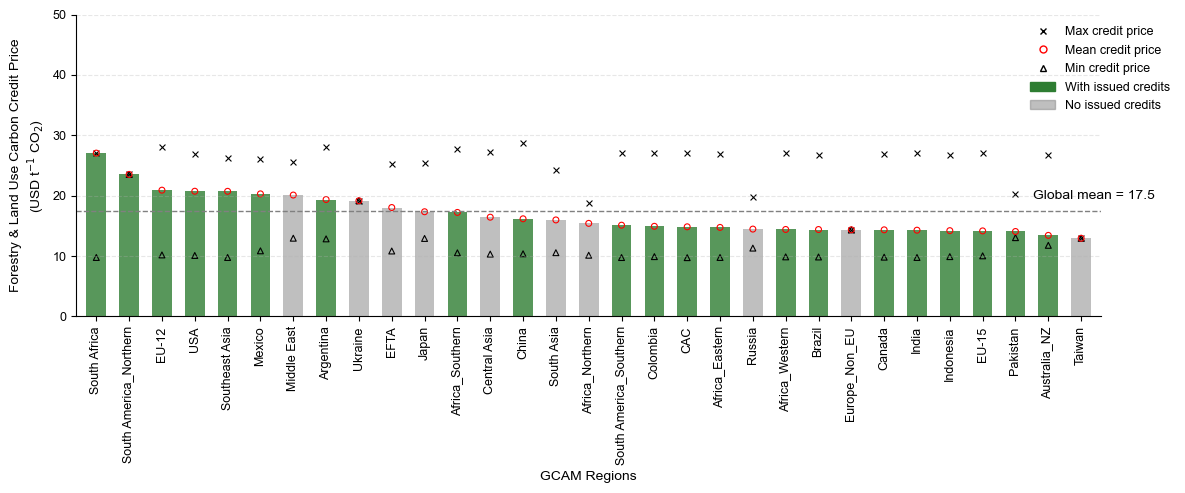

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "dejavusans",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

df = pd.read_excel("/Users/shirley/Desktop/forest restoration/forest_credit/output/FigSourceData/forestry_credit_prices_gcam.xlsx")

df["weighted_se"] = df["weighted_se"].replace([np.inf, -np.inf], np.nan).fillna(0)

df["ci_lower"] = df["weighted_mean_price"] - 1.96 * df["weighted_se"]
df["ci_upper"] = df["weighted_mean_price"] + 1.96 * df["weighted_se"]


df = df.sort_values("weighted_mean_price", ascending=False)
yerr = np.vstack([
    df["weighted_mean_price"] - df["ci_lower"],
    df["ci_upper"] - df["weighted_mean_price"]
])
yerr = np.maximum(0, yerr)
weights = df["total_credits"].fillna(0)
weighted_mean = (
    np.average(df["weighted_mean_price"], weights=weights)
    if weights.sum() > 0
    else df["weighted_mean_price"].mean()
)


fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df))

colors = np.where(
    (df["total_credits"].isna()) | (df["total_credits"] == 0),
    "gray",
    "#2E7D32"
)
alphas = np.where(colors == "gray", 0.5, 0.8)

for i in range(len(df)):
    ax.bar(
        x[i],
        df["weighted_mean_price"].iloc[i],
        color=colors[i],
        alpha=alphas[i],
        width=0.6
    )
# ax.errorbar(
#     x,
#     df["weighted_mean_price"],
#     yerr=yerr,
#     fmt='none',
#     ecolor='black',
#     elinewidth=1.2,
#     capsize=2
# )

ax.axhline(
    weighted_mean,
    color='grey',
    linestyle='--',
    linewidth=1
)


# ===== 最大值 =====
plt.scatter(
    x,
    df["max_price"],
    marker="x",              # 叉号，对应图中 Fuel excise tax 样式
    s=18,
    color="black",
    linewidths=0.8,
    label="Max"
)

# ===== 最小值 =====
plt.scatter(
    x,
    df["min_price"],
    marker="^",
    s=18,
    facecolors="none",      # 空心圆，对应图中 Explicit carbon tax 样式
    edgecolors="black",
    linewidths=0.8,
    label="Min"
)
# ===== 加权均值 =====
plt.scatter(
    x,
    df["weighted_mean_price"],
    marker="o",
    s=18,
    facecolors="none",      # 空心圆，对应图中 Explicit carbon tax 样式
    edgecolors="red",
    linewidths=0.8,
    label="Weighted mean"
)

ax.set_xticks(x)
ax.set_xticklabels(df["gcam_region"], rotation=90)

ax.set_ylabel("Forestry & Land Use Carbon Credit Price" + "\n" + "(USD t$^{-1}$ CO$_2$)")
ax.set_xlabel("GCAM Regions")
# for i, (v, upper) in enumerate(zip(df["weighted_mean_price"], df["ci_upper"])):
#     ax.text(
#         i,
#         upper + 0.8,
#         f"{v:.1f}",
#         ha='center',
#         va='bottom',
#         fontsize=9
#     )

ax.text(
    len(df) * 0.92,
    weighted_mean + 2,
    f"Global mean = {weighted_mean:.1f}",
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_ylim(0, 50)
ax.margins(x=0.01)
legend_elements = [
    mlines.Line2D([], [], marker="x", color="black",
                  linestyle="None", markersize=5, label="Max credit price"),
    mlines.Line2D([], [], marker="o",markerfacecolor="none", color="red",
                  linestyle="None", markersize=5, label="Mean credit price"),
    mlines.Line2D([], [], marker="^",markerfacecolor="none", color="black",
                  linestyle="None", markersize=5, label="Min credit price"),
    mpatches.Patch(color="#2E7D32", label="With issued credits"),
    mpatches.Patch(color="gray", alpha=0.5, label="No issued credits"),
    
]
ax.legend(handles=legend_elements, frameon=False,loc="upper left", bbox_to_anchor=(0.92, 1))

plt.tight_layout()
plt.savefig("/Users/shirley/Desktop/forest restoration/forest_credit/output/Fig/figure1b_forestry_credit_prices.pdf", dpi=600)

plt.show()

In [86]:
import re
import pandas as pd
import numpy as np


EUR_USD_2023 = 1.0824          # 2023年欧元兑美元年均汇率
CPI_1990 = 130.7               # 1990年CPI-U（1982-84=100）
CPI_2023 = 304.70              # 2023年CPI-U（1982-84=100）
TCO2_TO_TC = 44 / 12           # tCO2 -> tC 换算系数 ≈ 3.6667

DEFLATOR_1990 = CPI_1990 / CPI_2023                  # 2023美元 -> 1990美元 折算系数 ≈ 0.4289

other_countries = []

def map_to_gcam(country):
    if pd.isna(country):
        return None
    for region, countries in GCAM_MAPPING.items():
        for c in countries:
            if c.lower() in country.lower():
                return region
    other_countries.append(country)
    return "Other"

# ---------------- 读取数据 ----------------
df_price = pd.read_excel(
    "/Users/shirley/Desktop/forest restoration/forest_credit/data/OECD_net_carbon_price.xlsx",
    sheet_name="net_carbon_price", header=0
)
df_emission = pd.read_excel(
    "/Users/shirley/Desktop/forest restoration/forest_credit/data/OECD_net_carbon_price.xlsx",
    sheet_name="emission", header=0
)

df_price.columns = [
    re.sub(r"\s+", "_", str(col).replace("\n", " ").replace("\r", " ").strip())
    for col in df_price.columns
]
df_emission.columns = [
    re.sub(r"\s+", "_", str(col).replace("\n", " ").replace("\r", " ").strip())
    for col in df_emission.columns
]

# ---------------- price 和 emission 按国家（+年份）显式对齐 ----------------
df_emission_2023 = df_emission[df_emission["Year"] == 2023].copy()
df_emission_2023["Emission"] = pd.to_numeric(df_emission_2023["Emission"], errors="coerce")

df_price = df_price.merge(
    df_emission_2023[["Entity", "Code","Emission"]],
    left_on="REF_AREA", right_on="Code",
    how="left"
).rename(columns={"Emission": "total_emissions_issued"})

unmatched = df_price[df_price["total_emissions_issued"].isna()]["REF_AREA"].unique()
if len(unmatched) > 0:
    print("⚠️ 以下国家在emission表里没找到匹配，请检查国名拼写是否一致：")
    print(unmatched)

df_price["gcam_region"] = df_price["Entity"].apply(map_to_gcam)

# ---------------- 两套价格：2023美元（用于绝大多数字段）与1990美元（仅用于market_weighted_price） ----------------
df_price["carbon_price"]= pd.to_numeric(df_price["OBS_VALUE"], errors="coerce") * EUR_USD_2023       #2023 USD/tCO2eq
df_price["carbon_price_1990usd"] = df_price["carbon_price"] * TCO2_TO_TC * DEFLATOR_1990                                  # 1990 USD/tC

df_clean = df_price.dropna(subset=["carbon_price", "carbon_price_1990usd", "total_emissions_issued", "gcam_region"])

def weighted_avg(values, weights):
    values, weights = np.asarray(values), np.asarray(weights)
    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values, weights = values[mask], weights[mask]
    if len(weights) == 0 or weights.sum() == 0:
        return values.mean() if len(values) > 0 else np.nan
    return np.average(values, weights=weights)

def weighted_se(values, weights):
    values, weights = np.asarray(values), np.asarray(weights)
    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values, weights = values[mask], weights[mask]
    if len(weights) == 0 or weights.sum() == 0:
        return np.nan
    mean = np.average(values, weights=weights)
    numerator = np.sum(weights * (values - mean) ** 2)
    denominator = (np.sum(weights)) ** 2
    return np.sqrt(numerator / denominator)

# ---------------- 地区总排放量（分母：全部国家，不管有没有碳价） ----------------
df2 = df_emission[df_emission["Year"] == 2023].copy()
df2["Emission"] = pd.to_numeric(df2["Emission"], errors="coerce")
df2["gcam_region"] = df2["Entity"].apply(map_to_gcam)
region_total_emissions = df2.groupby("gcam_region")["Emission"].sum()
region_total_emissions = region_total_emissions.drop("Other", errors="ignore")

# ---------------- 分地区加权计算（全部用2023美元） ----------------
result = df_clean.groupby("gcam_region").apply(
    lambda g: pd.Series({
        "weighted_mean_price(2023 USD/tCo2eq)": weighted_avg(g["carbon_price"], g["total_emissions_issued"]),   # 2023 USD/tC
        "weighted_se(2023 USD/tCo2eq)": weighted_se(g["carbon_price"], g["total_emissions_issued"]),             # 2023 USD/tC
        "mean_price(2023 USD/tCo2eq)": g["carbon_price"].mean(),                                                   # 2023 USD/tC
        "std_price(2023 USD/tCo2eq)": g["carbon_price"].std(),                                                     # 2023 USD/tC
        "max_price(2023 USD/tCo2eq)": g["carbon_price"].max(),                                                     # 2023 USD/tC
        "min_price(2023 USD/tCo2eq)": g["carbon_price"].min(),                                                     # 2023 USD/tC
        "total_emissions": g["total_emissions_issued"].sum(),
        "n_projects": len(g),
        "region_total_emissions": region_total_emissions.get(g.name, np.nan),
        "market_proportion": (
            g["total_emissions_issued"].sum() / region_total_emissions.get(g.name, np.nan)
            if region_total_emissions.get(g.name, 0) > 0 else np.nan
        )
    })
).reset_index()

# ---------------- 仅market_weighted_price换算成1990美元（未定价国家按0元计入） ----------------
result["market_weighted_price(1990 USD/tC)"] = result["weighted_mean_price(2023 USD/tCo2eq)"] * TCO2_TO_TC* DEFLATOR_1990 * result["market_proportion"]  # 1990 USD/tC

print(result[["gcam_region", "weighted_mean_price(2023 USD/tCo2eq)", "market_proportion", "market_weighted_price(1990 USD/tC)"]])

result.to_excel(
    "/Users/shirley/Desktop/forest restoration/forest_credit/output/FigSourceData/fossil_carbon_prices_gcam.xlsx",
    index=False
)

⚠️ 以下国家在emission表里没找到匹配，请检查国名拼写是否一致：
['EU00_X' 'OECD00' 'G7' 'G20' 'ODA' 'E_O' 'W_X']
               gcam_region  weighted_mean_price(2023 USD/tCo2eq)  \
0           Africa_Eastern                              7.169936   
1          Africa_Northern                             -6.019364   
2          Africa_Southern                              2.515394   
3           Africa_Western                            -18.774812   
4                Argentina                              9.881263   
5             Australia_NZ                             23.148070   
6                   Brazil                              0.476070   
7                      CAC                             21.736589   
8                   Canada                             45.467696   
9             Central Asia                            -26.727653   
10                   China                              9.342518   
11                Colombia                             -9.939806   
12                    EFTA    

/var/folders/xt/zxpvbvsx2zb75gd2395zm9000000gn/T/ipykernel_71305/3953158027.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df_clean.groupby("gcam_region").apply(


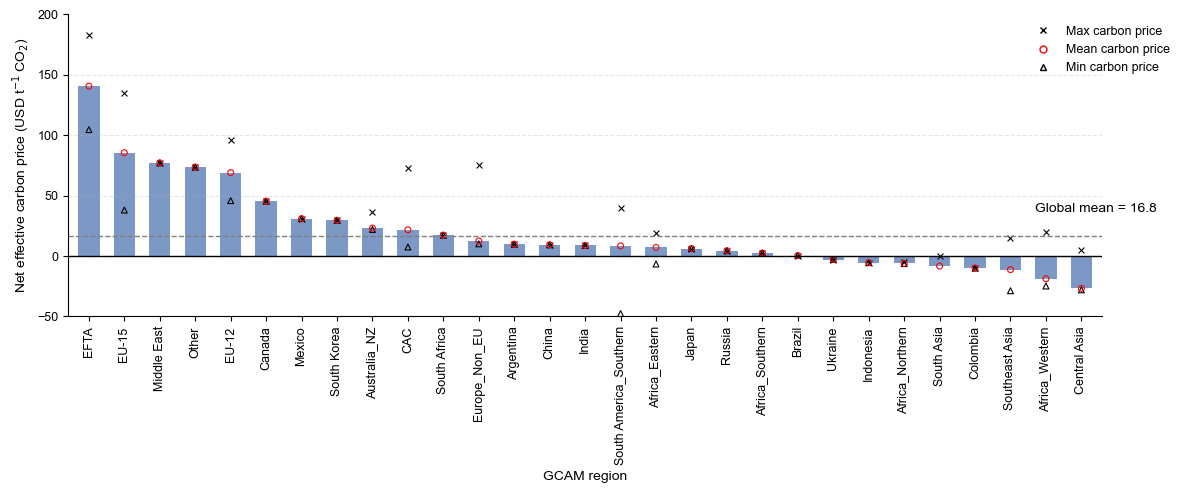

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "dejavusans",
    "font.size": 9,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

df = pd.read_excel("/Users/shirley/Desktop/forest restoration/forest_credit/output/FigSourceData/fossil_carbon_prices_gcam.xlsx")

df["weighted_se(2023 USD/tCo2eq)"] = df["weighted_se(2023 USD/tCo2eq)"].replace([np.inf, -np.inf], np.nan).fillna(0)

df["ci_lower"] = df["weighted_mean_price(2023 USD/tCo2eq)"] - 1.96 * df["weighted_se(2023 USD/tCo2eq)"]
df["ci_upper"] = df["weighted_mean_price(2023 USD/tCo2eq)"] + 1.96 * df["weighted_se(2023 USD/tCo2eq)"]


df = df.sort_values("weighted_mean_price(2023 USD/tCo2eq)", ascending=False)
yerr = np.vstack([
    df["weighted_mean_price(2023 USD/tCo2eq)"] - df["ci_lower"],
    df["ci_upper"] - df["weighted_mean_price(2023 USD/tCo2eq)"]
])
yerr = np.maximum(0, yerr)
weights = df["total_emissions"].fillna(0)
weighted_mean = (
    np.average(df["weighted_mean_price(2023 USD/tCo2eq)"], weights=weights)
    if weights.sum() > 0
    else df["weighted_mean_price(2023 USD/tCo2eq)"].mean()
)


fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df))

colors = np.where(
    (df["n_projects"].isna()) | (df["n_projects"] == 0),
    "#BECDFA",
    "#5B80B8"
)
alphas = np.where(colors == "gray", 0.5, 0.8)

for i in range(len(df)):
    ax.bar(
        x[i],
        df["weighted_mean_price(2023 USD/tCo2eq)"] .iloc[i],
        color=colors[i],
        alpha=alphas[i],
        width=0.6
    )
# ax.errorbar(
#     x,
#     df["weighted_mean_price"],
#     yerr=yerr,
#     fmt='none',
#     ecolor='black',
#     elinewidth=1.2,
#     capsize=2
# )

ax.axhline(
    weighted_mean,
    color='grey',
    linestyle='--',
    linewidth=1
)

ax.axhline(
    0,
    color='black',
    linestyle='-',
    linewidth=1
)

# ===== 最大值 =====
plt.scatter(
    x,
    df["max_price(2023 USD/tCo2eq)"],
    marker="x",              
    s=18,
    color="black",
    linewidths=0.8,
    label="Max"
)

# ===== 最小值 =====
plt.scatter(
    x,
    df["min_price(2023 USD/tCo2eq)"],
    marker="^",
    s=18,
    facecolors="none",      
    edgecolors="black",
    linewidths=0.8,
    label="Min"
)
# ===== 加权均值 =====
plt.scatter(
    x,
    df["weighted_mean_price(2023 USD/tCo2eq)"],
    marker="o",
    s=18,
    facecolors="none",      
    edgecolors="red",
    linewidths=0.8,
    label="Weighted mean"
)

ax.set_xticks(x)
ax.set_xticklabels(df["gcam_region"], rotation=90)

ax.set_ylabel("Net effective carbon price (USD t$^{-1}$ CO$_2$)")
ax.set_xlabel("GCAM region")
# for i, (v, upper) in enumerate(zip(df["weighted_mean_price(2023 USD/tCo2eq)"], df["ci_upper"])):
#     ax.text(
#         i,
#         upper + 4,
#         f"{v:.1f}",
#         ha='center',
#         va='bottom',
#         fontsize=9
#     )

ax.text(
    len(df) * 0.92,
    weighted_mean + 20,
    f"Global mean = {weighted_mean:.1f}",
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_ylim(-50, 200)
ax.margins(x=0.01)
legend_elements = [
     mlines.Line2D([], [], marker="x", color="black",
                  linestyle="None", markersize=5, label="Max carbon price"),
    mlines.Line2D([], [], marker="o",markerfacecolor="none", color="red",
                  linestyle="None", markersize=5, label="Mean carbon price"),
    mlines.Line2D([], [], marker="^",markerfacecolor="none", color="black",
                  linestyle="None", markersize=5, label="Min carbon price")
    
]
ax.legend(handles=legend_elements, frameon=False,loc="upper left", bbox_to_anchor=(0.92, 1))

plt.tight_layout()
plt.savefig("/Users/shirley/Desktop/forest restoration/forest_credit/output/Fig/figure1a_fossil_carbon_prices.pdf", dpi=600)

plt.show()